In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import sqlite3
import numpy as np

Data Connection
---

In [2]:
url_sales = "https://raw.githubusercontent.com/angelasc/ls_nautical_eda_visualization/refs/heads/main/fact_sales.csv"
url_costs = "https://raw.githubusercontent.com/angelascolombo/ls_nautical_etl_pipeline/refs/heads/main/datasets_final/fact_costs.csv"
url_products = "https://raw.githubusercontent.com/angelasc/ls_nautical_eda_visualization/refs/heads/main/dim_products.csv"
url_customers = "https://raw.githubusercontent.com/angelasc/ls_nautical_eda_visualization/refs/heads/main/dim_customers.csv"
url_financial = "https://raw.githubusercontent.com/angelasc/ls_nautical_eda_visualization/refs/heads/main/aux_financial_summary.csv"

In [3]:
# GitHub Connection

try:
    fact_sales = pd.read_csv(url_sales, sep=';')
    fact_costs = pd.read_csv(url_costs, sep=';')
    dim_products = pd.read_csv(url_products, sep=';')
    dim_customers = pd.read_csv(url_customers, sep=';')
    aux_financial = pd.read_csv(url_financial, sep=';')
    print("✅ Data successfully downloaded from GitHub")
except Exception as e:
    print("❌ Error downloading data. Check the public GitHub links.")
    print(e)

✅ Data successfully downloaded from GitHub


In [4]:
# Database creation (SQLite)
conn = sqlite3.connect(':memory:')

# DataFrames creation
fact_sales.to_sql('fact_sales', conn, index=False, if_exists='replace')
fact_costs.to_sql('fact_costs', conn, index=False, if_exists='replace')
dim_products.to_sql('dim_products', conn, index=False, if_exists='replace')
dim_customers.to_sql('dim_customers', conn, index=False, if_exists='replace')
aux_financial.to_sql('aux_financial_summary', conn, index=False, if_exists='replace')
print("✅ SQL database successfully structured")

✅ SQL database successfully structured


**1. Margem de Lucro por Produto**
---

*Profit Margin by Product*

In [5]:
query_1 = """
SELECT
    s.product_id,
    p.product_name,
    ROUND(SUM(COALESCE(afs.gross_profit_brl, 0))) AS total_gross_profit_brl,
    ROUND((SUM(COALESCE(afs.gross_profit_brl, 0)) / NULLIF(SUM(s.sale_total_brl), 0)) * 100, 2) AS margin_percentage

FROM fact_sales AS s
  LEFT JOIN dim_products AS p
  ON s.product_id = p.product_id
  LEFT JOIN aux_financial_summary AS afs
  ON s.sale_id = afs.sale_id

GROUP BY
    s.product_id,
    p.product_name

ORDER BY
    margin_percentage DESC;
"""

df_1 = pd.read_sql_query(query_1, conn)

/tmp/ipykernel_1229/222336668.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


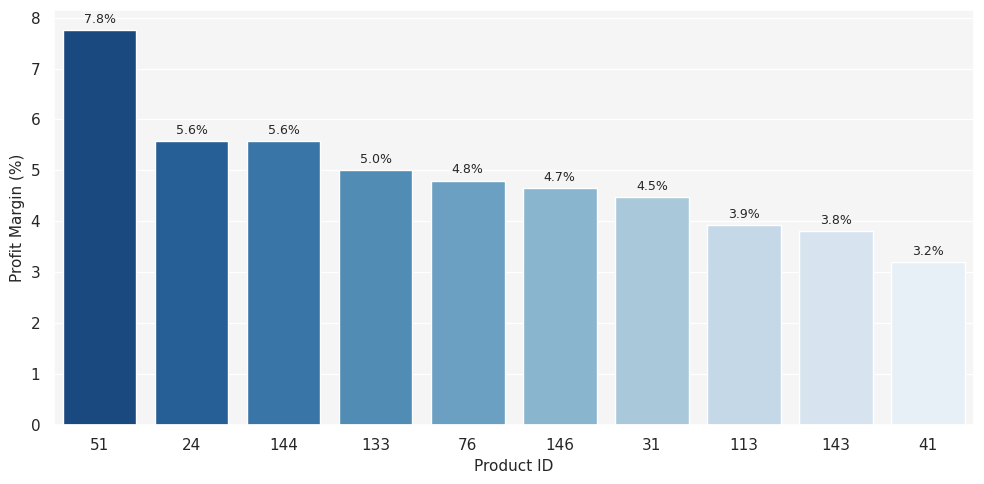

In [6]:
# Top 10 produtos com MAIOR margem de lucro
# Top 10 HIGHEST profit margins products

plot_1_a = df_1.dropna(subset=['product_id']).copy()
plot_1_a['product_id'] = plot_1_a['product_id'].astype(int)
df_highest_top10 = plot_1_a.sort_values(by='margin_percentage', ascending=False).head(10)

plt.figure(figsize=(10, 5))

# Style definition
sns.set_theme(rc={'axes.facecolor': '#f5f5f5', 'figure.facecolor': '#f5f5f5'})
sns.despine(left=True, bottom=True)

# Values
ax1 = sns.barplot(
    data=df_highest_top10,
    x='product_id',
    y='margin_percentage',
    palette='Blues_r',
    order=df_highest_top10['product_id']
)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.xlabel('Product ID', fontsize=11)
plt.ylabel('Profit Margin (%)', fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1229/4006133259.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


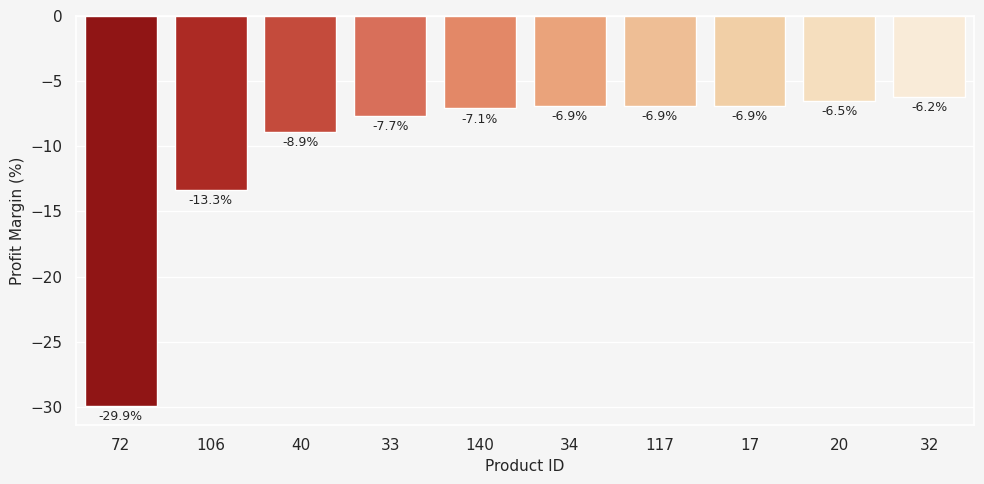

In [7]:
# Top 10 produtos com MENOR margem de lucro
# Top 10 LOWEST profit margins products

plot_1_b = df_1.dropna(subset=['product_id']).copy()
plot_1_b['product_id'] = plot_1_b['product_id'].astype(int)
df_lowest_top10 = plot_1_b.sort_values(by='margin_percentage', ascending=True).head(10)

plt.figure(figsize=(10, 5))

# Style definition
sns.set_theme(rc={'axes.facecolor': '#f5f5f5', 'figure.facecolor': '#f5f5f5'})
sns.despine(left=True, bottom=True)

# Values
ax1 = sns.barplot(
    data=df_lowest_top10,
    x='product_id',
    y='margin_percentage',
    palette='OrRd_r',
    order=df_lowest_top10['product_id']
)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.xlabel('Product ID', fontsize=11)
plt.ylabel('Profit Margin (%)', fontsize=11)

plt.tight_layout()
plt.show()

**2. Performance de vendas por Categoria de Produto**
---
*Sales performance by Product Category*

In [8]:
query_2 = """
SELECT
    p.product_category,
    ROUND(SUM(afs.sale_total_BRL)) AS total_sale_brl,
    ROUND(SUM(afs.total_cost_BRL)) AS total_cost_brl,
    ROUND(SUM(afs.gross_profit_BRL)) as financial_result_brl,
    ROUND((SUM(COALESCE(afs.gross_profit_BRL, 0)) / NULLIF(SUM(fs.sale_total_BRL), 0)) * 100, 2) AS margin_percentage

FROM aux_financial_summary AS afs
  LEFT JOIN fact_sales AS fs
  ON afs.sale_id = fs.sale_id
  LEFT JOIN dim_products AS p
  ON fs.product_id = p.product_id

GROUP BY p.product_category
ORDER BY margin_percentage DESC;
"""

df_2 = pd.read_sql_query(query_2, conn)

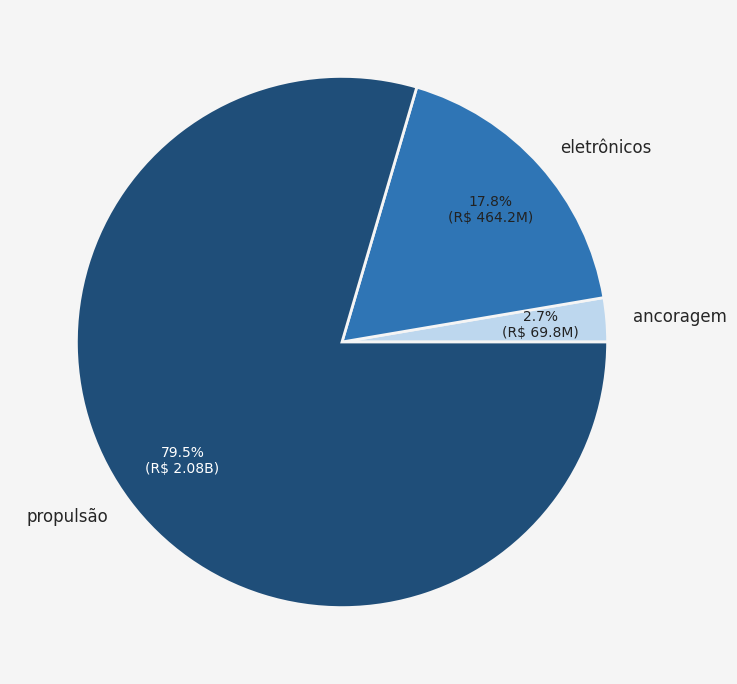

In [9]:
plot_2_a = df_2.dropna(subset=['product_category']).copy()
plot_2_a = plot_2_a[plot_2_a['total_sale_brl'] > 0]
plot_2_a = plot_2_a.reset_index(drop=True)

plt.figure(figsize=(10, 7))

# Style definition
plt.gcf().set_facecolor('#f5f5f5')
cores = ['#bdd7ee', '#2f75b5', '#1f4e79']

# Values
wedges, texts, autotexts = plt.pie(
    plot_2_a['total_sale_brl'],
    labels=plot_2_a['product_category'],
    autopct='%1.1f%%',
    colors=cores,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': '#f5f5f5', 'linewidth': 2},
    pctdistance=0.75
)

# Text customization
for i, row in plot_2_a.iterrows():
    categoria = row['product_category']
    venda_brl = row['total_sale_brl']

    # Dynamic formatting
    if venda_brl >= 1e9:
        venda_formatada = f"R$ {venda_brl / 1e9:.2f}B"
    else:
        venda_formatada = f"R$ {venda_brl / 1e6:.1f}M"

    novo_texto_fatia = f"{autotexts[i].get_text()}\n({venda_formatada})"
    autotexts[i].set_text(novo_texto_fatia)
    autotexts[i].set_fontsize(10)

    if categoria.lower() == 'propulsão':
        autotexts[i].set_color('white')
    else:
        autotexts[i].set_color('#222222')

plt.tight_layout()
plt.show()

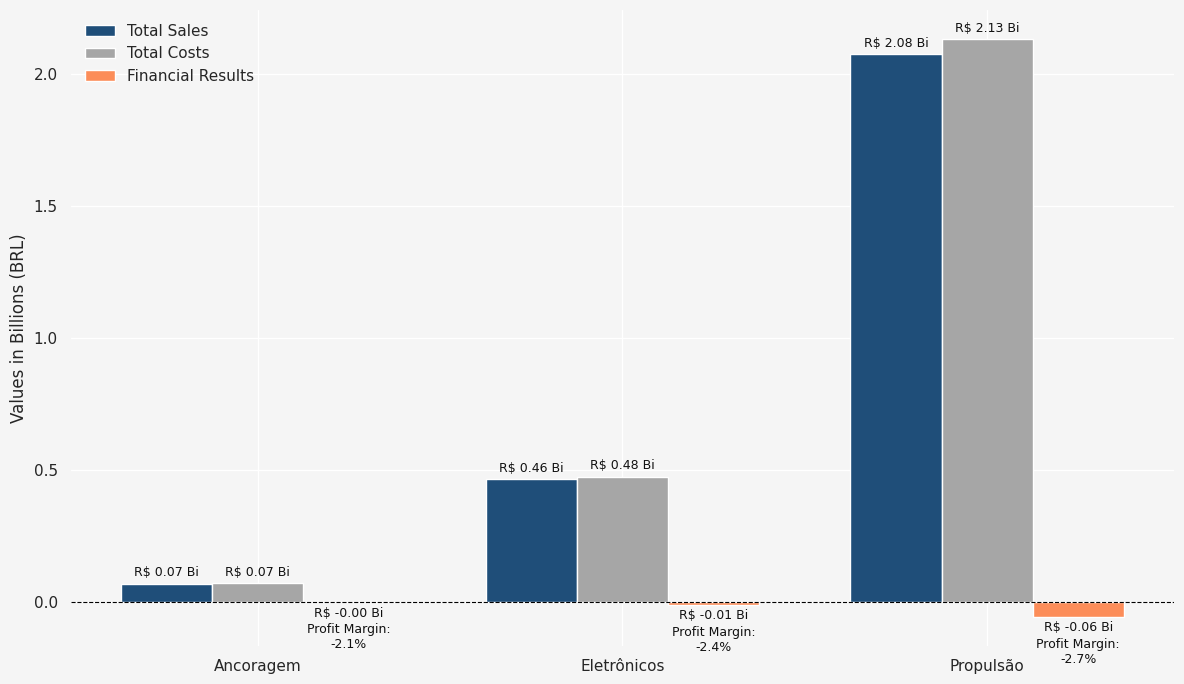

In [10]:
plot_2_b = df_2.dropna(subset=['product_category']).copy().reset_index(drop=True)

# Money adjustmets
plot_2_b['total_sale_b'] = plot_2_b['total_sale_brl'] / 1e9
plot_2_b['total_cost_b'] = plot_2_b['total_cost_brl'] / 1e9
plot_2_b['financial_result_b'] = plot_2_b['financial_result_brl'] / 1e9

# Style Definition
x = np.arange(len(plot_2_b['product_category']))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f5f5f5')
ax.set_facecolor('#f5f5f5')

# Values
rects1 = ax.bar(x - width, plot_2_b['total_sale_b'], width, label='Total Sales', color='#1f4e79')
rects2 = ax.bar(x, plot_2_b['total_cost_b'], width, label='Total Costs', color='#a6a6a6')
rects3 = ax.bar(x + width, plot_2_b['financial_result_b'], width, label='Financial Results', color='#FC8D59')

# Margin Percentage
for i, rect in enumerate(rects3):
    height = rect.get_height()
    margem = plot_2_b.loc[i, 'margin_percentage']

    va_direction = 'bottom' if height >= 0 else 'top'
    offset = 0.03 if height >= 0 else -0.05

    ax.annotate(
        f'Profit Margin:\n{margem:.1f}%',
        xy=(rect.get_x() + rect.get_width() / 2, height),
        xytext=(0, 3 if height >= 0 else -15),
        textcoords="offset points",
        ha='center', va=va_direction,
        fontsize=9, color='#111111'
    )

# Customization
ax.bar_label(rects1, fmt='R$ %.2f Bi', padding=3, fontsize=9, color='#111111')
ax.bar_label(rects2, fmt='R$ %.2f Bi', padding=3, fontsize=9, color='#111111')
ax.bar_label(rects3, fmt='R$ %.2f Bi', padding=3, fontsize=9, color='#111111')
ax.set_ylabel('Values ​​in Billions (BRL)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([cat.capitalize() for cat in plot_2_b['product_category']], fontsize=11)


ax.axhline(0, color='black', linewidth=0.8, linestyle='--')


ax.legend(loc='upper left', frameon=False, fontsize=11)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

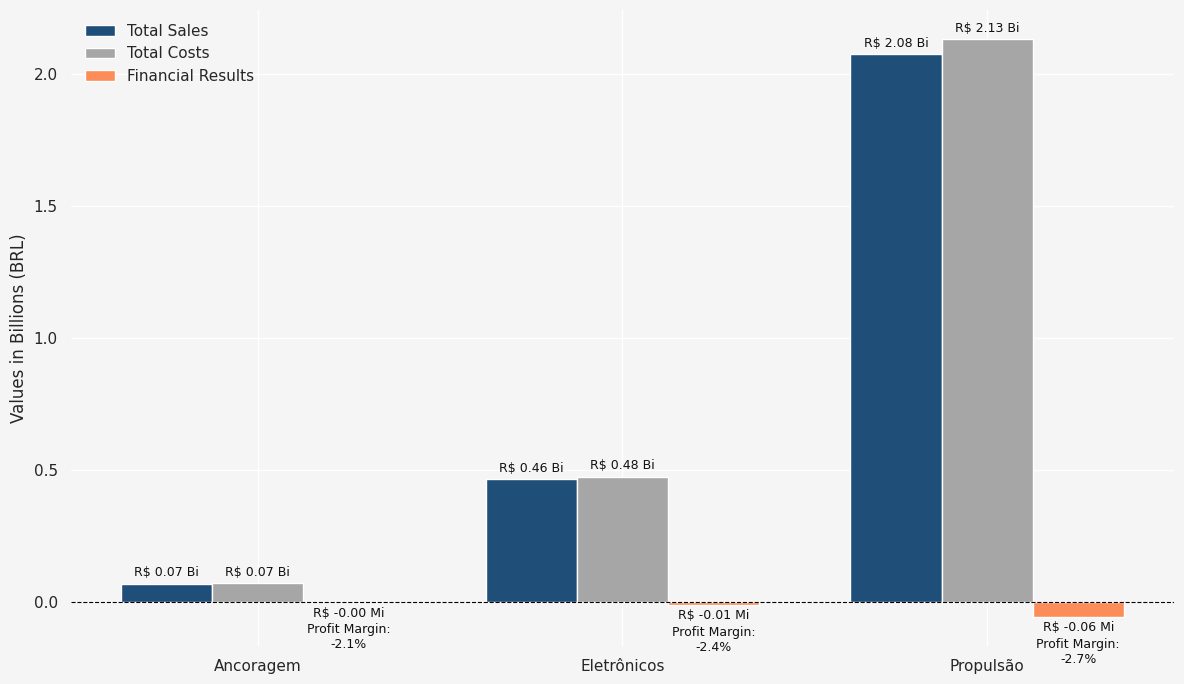

In [19]:
plot_2_b = df_2.dropna(subset=['product_category']).copy().reset_index(drop=True)

# Money adjustmets
plot_2_b['total_sale_b'] = plot_2_b['total_sale_brl'] / 1e9
plot_2_b['total_cost_b'] = plot_2_b['total_cost_brl'] / 1e9
plot_2_b['financial_result_b'] = plot_2_b['financial_result_brl'] / 1e9

# Style Definition
x = np.arange(len(plot_2_b['product_category']))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f5f5f5')
ax.set_facecolor('#f5f5f5')

# Values
rects1 = ax.bar(x - width, plot_2_b['total_sale_b'], width, label='Total Sales', color='#1f4e79')
rects2 = ax.bar(x, plot_2_b['total_cost_b'], width, label='Total Costs', color='#a6a6a6')
rects3 = ax.bar(x + width, plot_2_b['financial_result_b'], width, label='Financial Results', color='#FC8D59')

# Margin Percentage
for i, rect in enumerate(rects3):
    height = rect.get_height()
    margem = plot_2_b.loc[i, 'margin_percentage']

    va_direction = 'bottom' if height >= 0 else 'top'
    offset = 0.03 if height >= 0 else -0.05

    ax.annotate(
        f'Profit Margin:\n{margem:.1f}%',
        xy=(rect.get_x() + rect.get_width() / 2, height),
        xytext=(0, 3 if height >= 0 else -15),
        textcoords="offset points",
        ha='center', va=va_direction,
        fontsize=9, color='#111111'
    )

# Customization
ax.bar_label(rects1, fmt='R$ %.2f Bi', padding=3, fontsize=9, color='#111111')
ax.bar_label(rects2, fmt='R$ %.2f Bi', padding=3, fontsize=9, color='#111111')
ax.bar_label(rects3, fmt='R$ %.2f Mi', padding=3, fontsize=9, color='#111111')
ax.set_ylabel('Values ​​in Billions (BRL)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([cat.capitalize() for cat in plot_2_b['product_category']], fontsize=11)


ax.axhline(0, color='black', linewidth=0.8, linestyle='--')


ax.legend(loc='upper left', frameon=False, fontsize=11)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**3. Sazonalidade de Vendas**
---
*Sales Sazonality*

In [11]:
query_3 = """

  -- Agrupamento da receita por Ano-Mês para criação da série temporal
  -- Revenue grouping by Year-Month to create the time series
WITH monthly_revenue AS (
    SELECT
        strftime('%Y-%m', sale_date) AS year_month,
        SUM(sale_total_brl) AS revenue
    FROM fact_sales
    GROUP BY year_month
),

  -- 12-month moving average calculation
moving_average_12m AS (
    SELECT
        year_month,
        revenue,
        AVG(revenue) OVER (
            ORDER BY year_month
            ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
        ) AS moving_avg_12m
    FROM monthly_revenue
)

SELECT
    year_month,
    ROUND(revenue, 2) AS total_sales_brl,
    ROUND(moving_avg_12m, 2) AS moving_avg
FROM moving_average_12m
WHERE moving_avg_12m > 0
ORDER BY year_month;
"""

df_3 = pd.read_sql_query(query_3, conn)

In [12]:
# Date values formatting
df_3['year_month'] = pd.to_datetime(df_3['year_month'])
df_3['month'] = df_3['year_month'].dt.month
df_3["year"] = df_3["year_month"].dt.year

# Monetary values formatting
df_3['revenue_millions'] = df_3['total_sales_brl'] / 1e6
df_3['moving_average_millions'] = df_3['moving_avg'] / 1e6

# Values sorting ​​by year
df_3_2023 = df_3[df_3['year_month'].dt.year == 2023].sort_values(by='year_month')
df_3_2024 = df_3[df_3['year_month'].dt.year == 2024].sort_values(by='year_month')

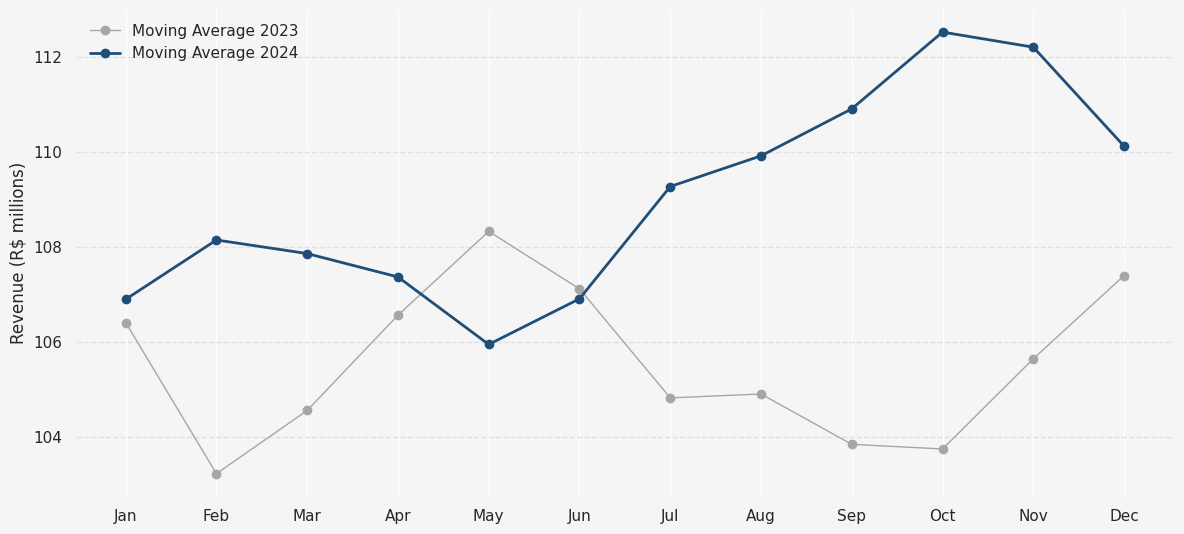

In [13]:
# 2. Moving Average by Month

# Style definition
plt.figure(figsize=(12, 5.5))
plt.gcf().set_facecolor('#f5f5f5')
ax = plt.gca()
ax.set_facecolor('#f5f5f5')

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Plotting
plt.plot(df_3_2023['month'], df_3_2023['moving_average_millions'],
         marker='o', linewidth=1, color='#a6a6a6', label='Moving Average 2023')
plt.plot(df_3_2024['month'], df_3_2024['moving_average_millions'],
         marker='o', linewidth=2, color='#1f4e79', label='Moving Average 2024')

# Values
nomes_meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), nomes_meses, fontsize=11)
plt.ylabel('Revenue (R$ millions)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')
plt.legend(loc='upper left', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()